<a href="https://www.kaggle.com/code/lalit7881/fifa-world-cup-2026-match-eda-100?scriptVersionId=328153388" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/swaptr/fifa-wc-2026-matches/matches.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/swaptr/fifa-wc-2026-matches/matches.csv")

In [3]:
df.head()

,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
0,Group stage,1,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2,0,...,11,3,1,12,8,8,7,1.0,1.0,NaN
1,Group stage,1,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2,1,...,16,4,5,12,15,11,7,2.0,2.0,NaN
2,Group stage,1,Fri,2026-06-12,15:00,Canada,Bosnia & Herz.,1–1,1,1,...,20,9,4,24,10,4,10,1.0,0.0,NaN
3,Group stage,1,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4,1,...,17,3,1,17,5,11,9,2.0,1.0,NaN
4,Group stage,1,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1,1,...,11,3,10,8,35,10,7,0.0,1.0,NaN


In [4]:
df.tail()

,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
15,Group stage,1,Mon,2026-06-15,18:00,Saudi Arabia,Uruguay,1–1,1,1,...,6,4,14,7,47,7,10,0.0,6.0,NaN
16,Group stage,1,Tue,2026-06-16,15:00,France,Senegal,3–1,3,1,...,9,6,4,9,9,7,8,1.0,3.0,NaN
17,Group stage,1,Tue,2026-06-16,18:00,Iraq,Norway,1–4,1,4,...,13,2,5,13,17,5,3,1.0,0.0,NaN
18,Group stage,1,Tue,2026-06-16,20:00,Argentina,Algeria,3–0,3,0,...,8,2,2,5,8,12,8,3.0,1.0,NaN
19,Group stage,1,Tue,2026-06-16,21:00,Austria,Jordan,3–1,3,1,...,7,4,3,17,15,15,12,3.0,1.0,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   round               20 non-null     object 
 1   gameweek            20 non-null     int64  
 2   dayofweek           20 non-null     object 
 3   date                20 non-null     object 
 4   start_time          20 non-null     object 
 5   home_team           20 non-null     object 
 6   away_team           20 non-null     object 
 7   score               20 non-null     object 
 8   home_score          20 non-null     int64  
 9   away_score          20 non-null     int64  
 10  attendance          20 non-null     object 
 11  venue               20 non-null     object 
 12  referee             20 non-null     object 
 13  home_formation      20 non-null     object 
 14  away_formation      20 non-null     object 
 15  home_manager        20 non-null     object 
 16  away_manag

In [6]:
df.describe()

,gameweek,home_score,away_score,home_possession,away_possession,home_sot,away_sot,home_total_shots,away_total_shots,home_saves,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
count,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,19.000000,19.000000,0.0
mean,1.0,2.100000,1.000000,52.450000,47.600000,5.000000,3.550000,13.800000,11.950000,2.600000,...,11.000000,4.600000,4.150000,15.000000,15.500000,8.500000,8.700000,1.368421,1.684211,NaN
std,0.0,1.713722,0.917663,12.227988,12.193182,2.406133,2.723678,5.237516,7.437282,2.500526,...,5.191085,2.392972,3.422449,7.262014,10.440307,2.874571,3.961658,1.116071,1.796683,NaN
min,1.0,0.000000,0.000000,28.000000,26.000000,1.000000,0.000000,7.000000,3.000000,0.000000,...,1.000000,2.000000,1.000000,5.000000,4.000000,4.000000,3.000000,0.000000,0.000000,NaN
25%,1.0,1.000000,0.750000,48.000000,38.750000,4.000000,2.000000,10.750000,7.000000,1.000000,...,7.750000,3.000000,1.750000,11.250000,8.750000,6.000000,5.750000,0.500000,1.000000,NaN
50%,1.0,2.000000,1.000000,54.000000,46.000000,4.000000,3.000000,13.000000,9.500000,2.000000,...,11.000000,4.000000,3.500000,13.500000,13.500000,8.000000,8.000000,1.000000,1.000000,NaN
75%,1.0,3.000000,1.000000,61.250000,52.000000,6.000000,4.250000,15.250000,14.000000,3.000000,...,14.250000,5.250000,5.000000,17.500000,15.500000,11.000000,12.000000,2.000000,2.500000,NaN
max,1.0,7.000000,4.000000,74.000000,72.000000,12.000000,10.000000,27.000000,30.000000,9.000000,...,21.000000,11.000000,14.000000,36.000000,47.000000,15.000000,16.000000,3.000000,6.000000,NaN


In [7]:
df.isnull()

,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [8]:
df.isnull().sum()

round                  0
gameweek               0
dayofweek              0
date                   0
start_time             0
home_team              0
away_team              0
score                  0
home_score             0
away_score             0
attendance             0
venue                  0
referee                0
home_formation         0
away_formation         0
home_manager           0
away_manager           0
home_captain           0
away_captain           0
home_possession        0
away_possession        0
home_sot               0
away_sot               0
home_total_shots       0
away_total_shots       0
home_saves             0
away_saves             0
home_cards_yellow      0
away_cards_yellow      0
home_cards_red         0
away_cards_red         0
home_fouls             0
away_fouls             0
home_corners           0
away_corners           0
home_crosses           0
away_crosses           0
home_interceptions     0
away_interceptions     0
home_offsides          1


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

round                  object
gameweek                int64
dayofweek              object
date                   object
start_time             object
home_team              object
away_team              object
score                  object
home_score              int64
away_score              int64
attendance             object
venue                  object
referee                object
home_formation         object
away_formation         object
home_manager           object
away_manager           object
home_captain           object
away_captain           object
home_possession         int64
away_possession         int64
home_sot                int64
away_sot                int64
home_total_shots        int64
away_total_shots        int64
home_saves              int64
away_saves              int64
home_cards_yellow       int64
away_cards_yellow       int64
home_cards_red          int64
away_cards_red          int64
home_fouls              int64
away_fouls              int64
home_corne

In [11]:
df.shape

(20, 42)

In [12]:
df.columns

Index(['round', 'gameweek', 'dayofweek', 'date', 'start_time', 'home_team',
       'away_team', 'score', 'home_score', 'away_score', 'attendance', 'venue',
       'referee', 'home_formation', 'away_formation', 'home_manager',
       'away_manager', 'home_captain', 'away_captain', 'home_possession',
       'away_possession', 'home_sot', 'away_sot', 'home_total_shots',
       'away_total_shots', 'home_saves', 'away_saves', 'home_cards_yellow',
       'away_cards_yellow', 'home_cards_red', 'away_cards_red', 'home_fouls',
       'away_fouls', 'home_corners', 'away_corners', 'home_crosses',
       'away_crosses', 'home_interceptions', 'away_interceptions',
       'home_offsides', 'away_offsides', 'notes'],
      dtype='object')

In [13]:
df.nunique()

round                  1
gameweek               1
dayofweek              6
date                   6
start_time             7
home_team             20
away_team             20
score                 13
home_score             7
away_score             4
attendance            20
venue                 16
referee               20
home_formation         6
away_formation         7
home_manager          20
away_manager          20
home_captain          20
away_captain          20
home_possession       14
away_possession       14
home_sot               9
away_sot               9
home_total_shots      11
away_total_shots      12
home_saves             8
away_saves             7
home_cards_yellow      4
away_cards_yellow      5
home_cards_red         2
away_cards_red         2
home_fouls            11
away_fouls            14
home_corners           8
away_corners           9
home_crosses          14
away_crosses          15
home_interceptions     9
away_interceptions    11
home_offsides          4


## EDA

Dataset Shape : (20, 42)
         round  gameweek dayofweek       date start_time       home_team  \
0  Group stage         1       Thu 2026-06-11      13:00          Mexico   
1  Group stage         1       Thu 2026-06-11      20:00  Korea Republic   
2  Group stage         1       Fri 2026-06-12      15:00          Canada   
3  Group stage         1       Fri 2026-06-12      18:00   United States   
4  Group stage         1       Sat 2026-06-13      12:00           Qatar   

        away_team score  home_score  away_score  ...  away_fouls home_corners  \
0    South Africa   2–0           2           0  ...          11            3   
1         Czechia   2–1           2           1  ...          16            4   
2  Bosnia & Herz.   1–1           1           1  ...          20            9   
3        Paraguay   4–1           4           1  ...          17            3   
4     Switzerland   1–1           1           1  ...          11            3   

  away_corners home_crosses awa

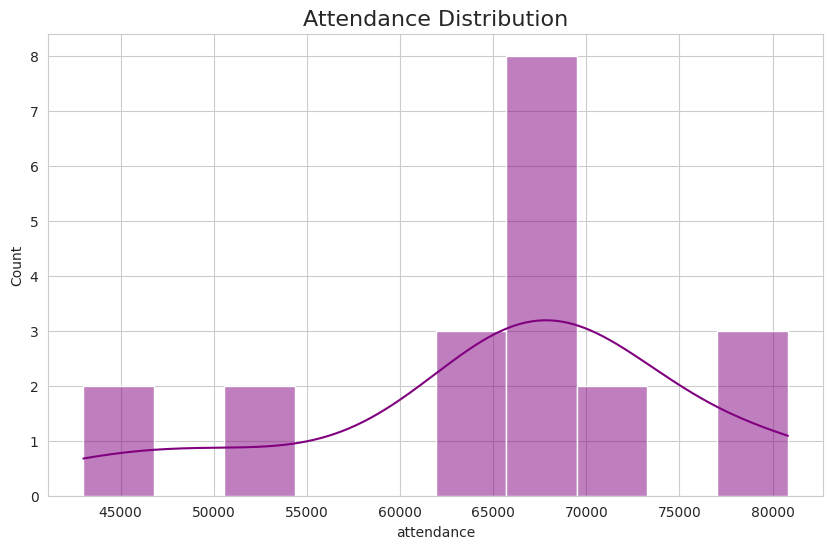

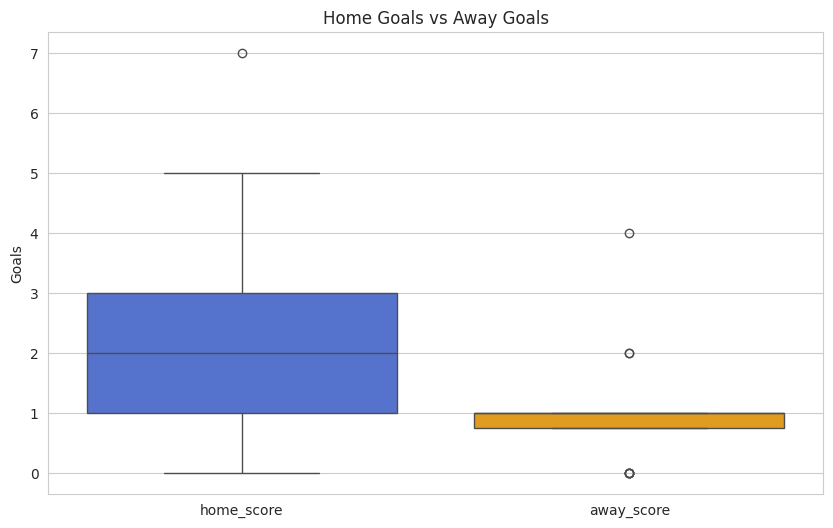

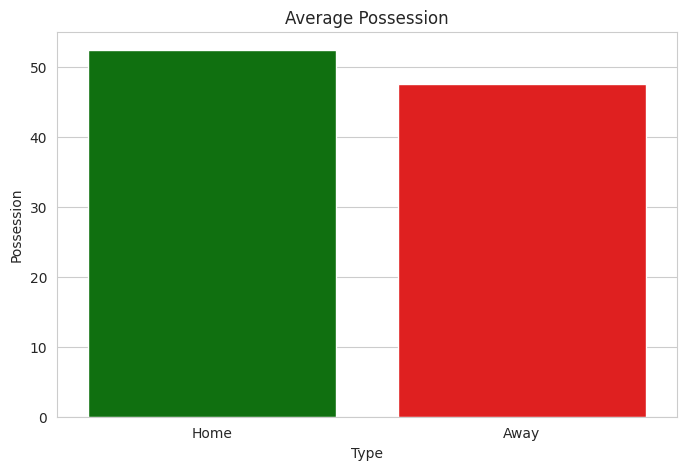

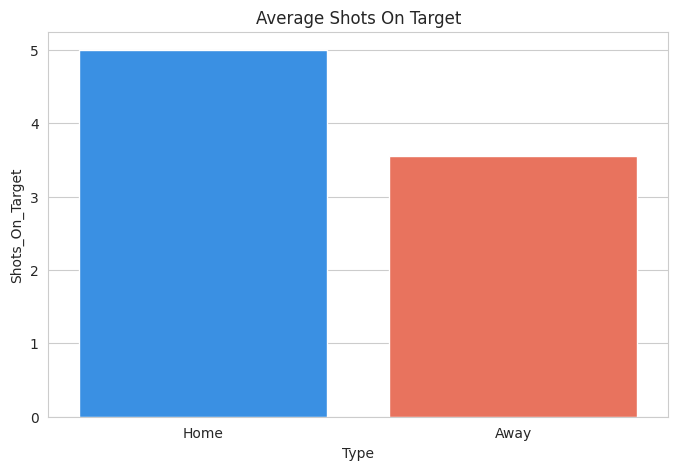

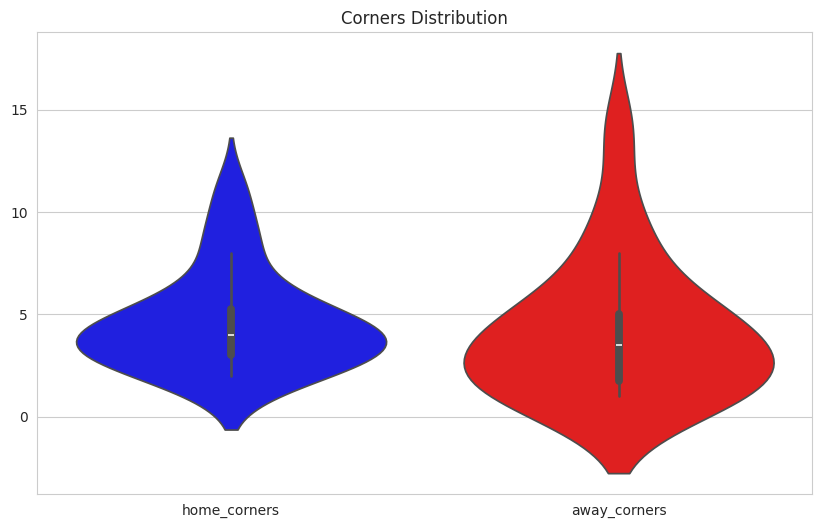

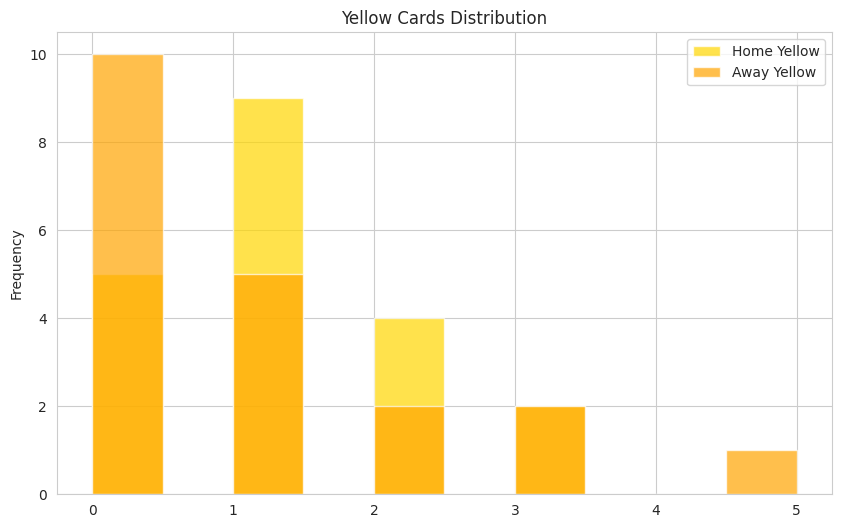

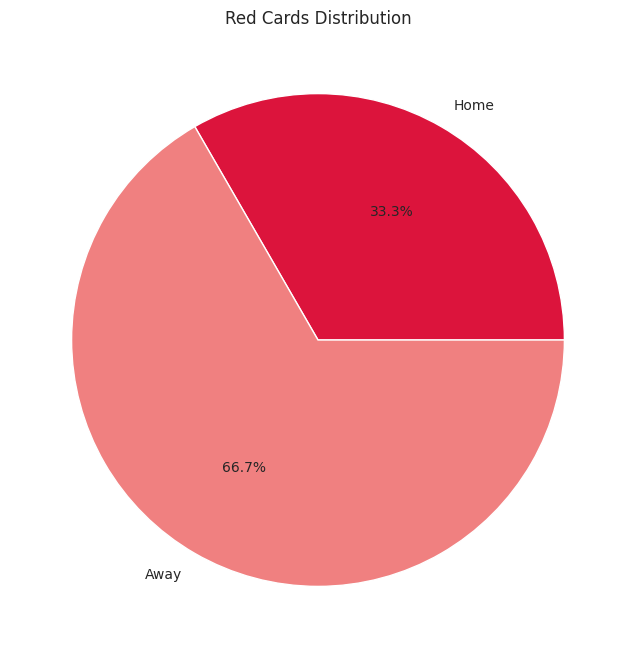

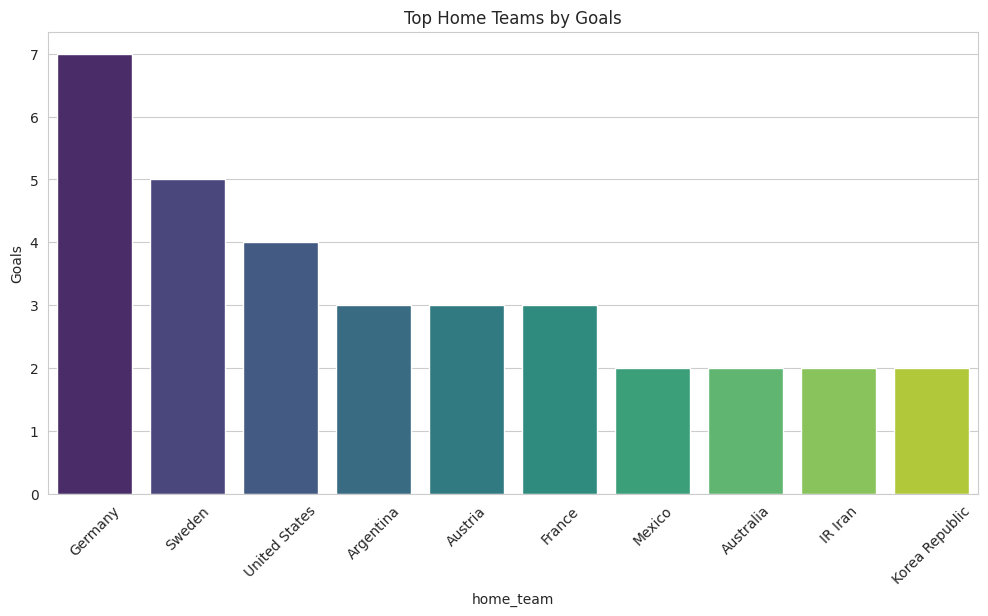

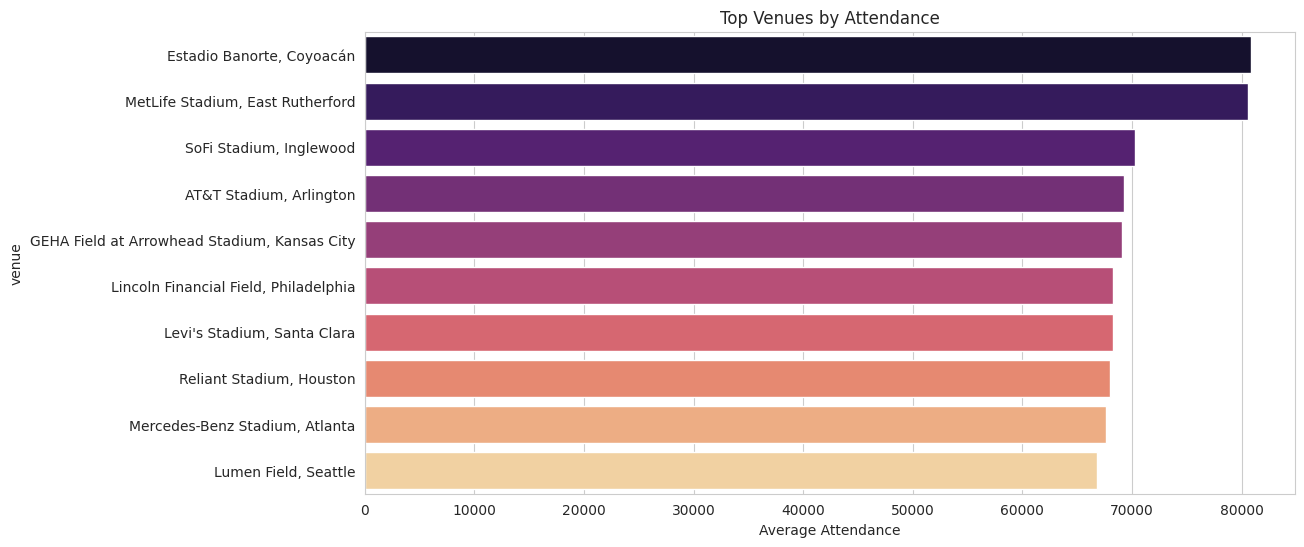

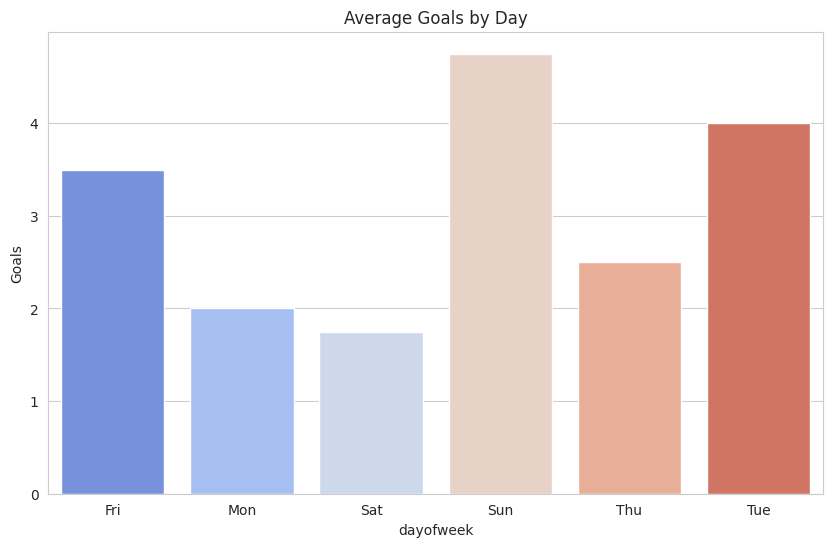

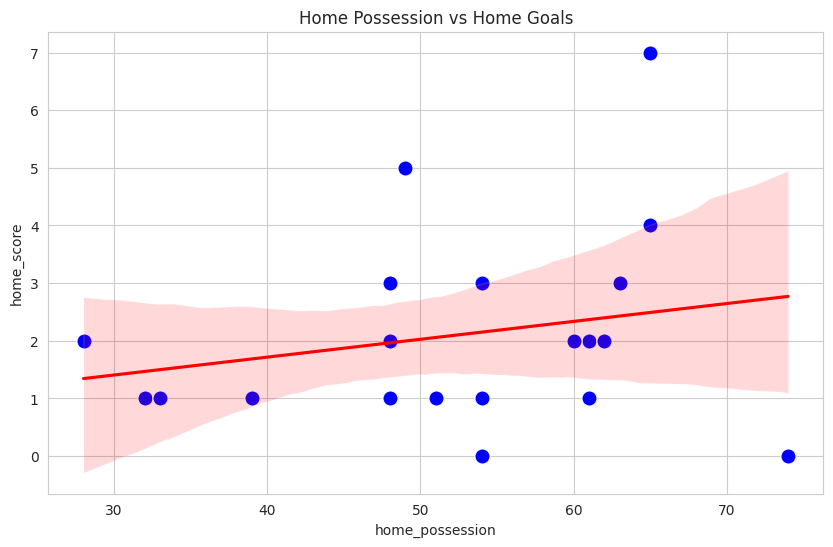

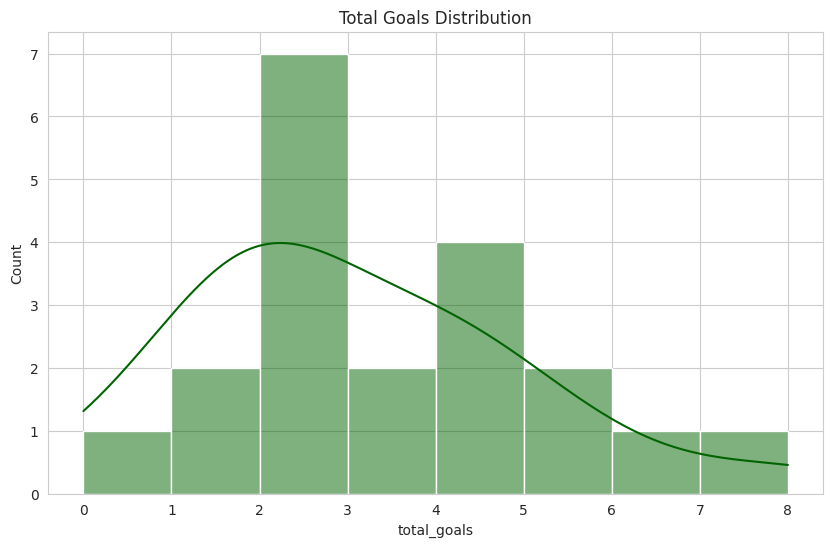

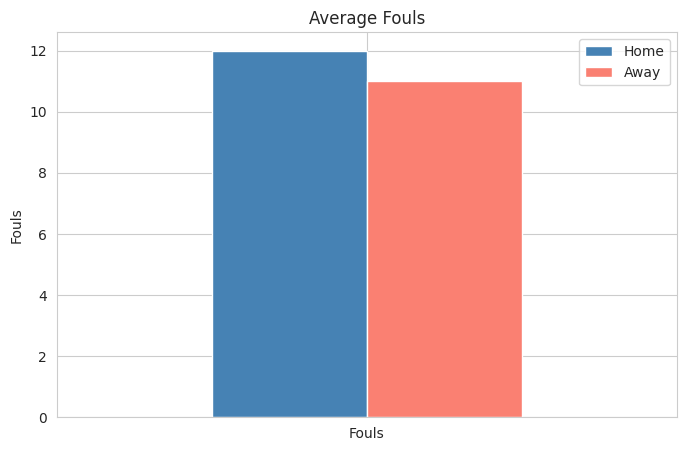

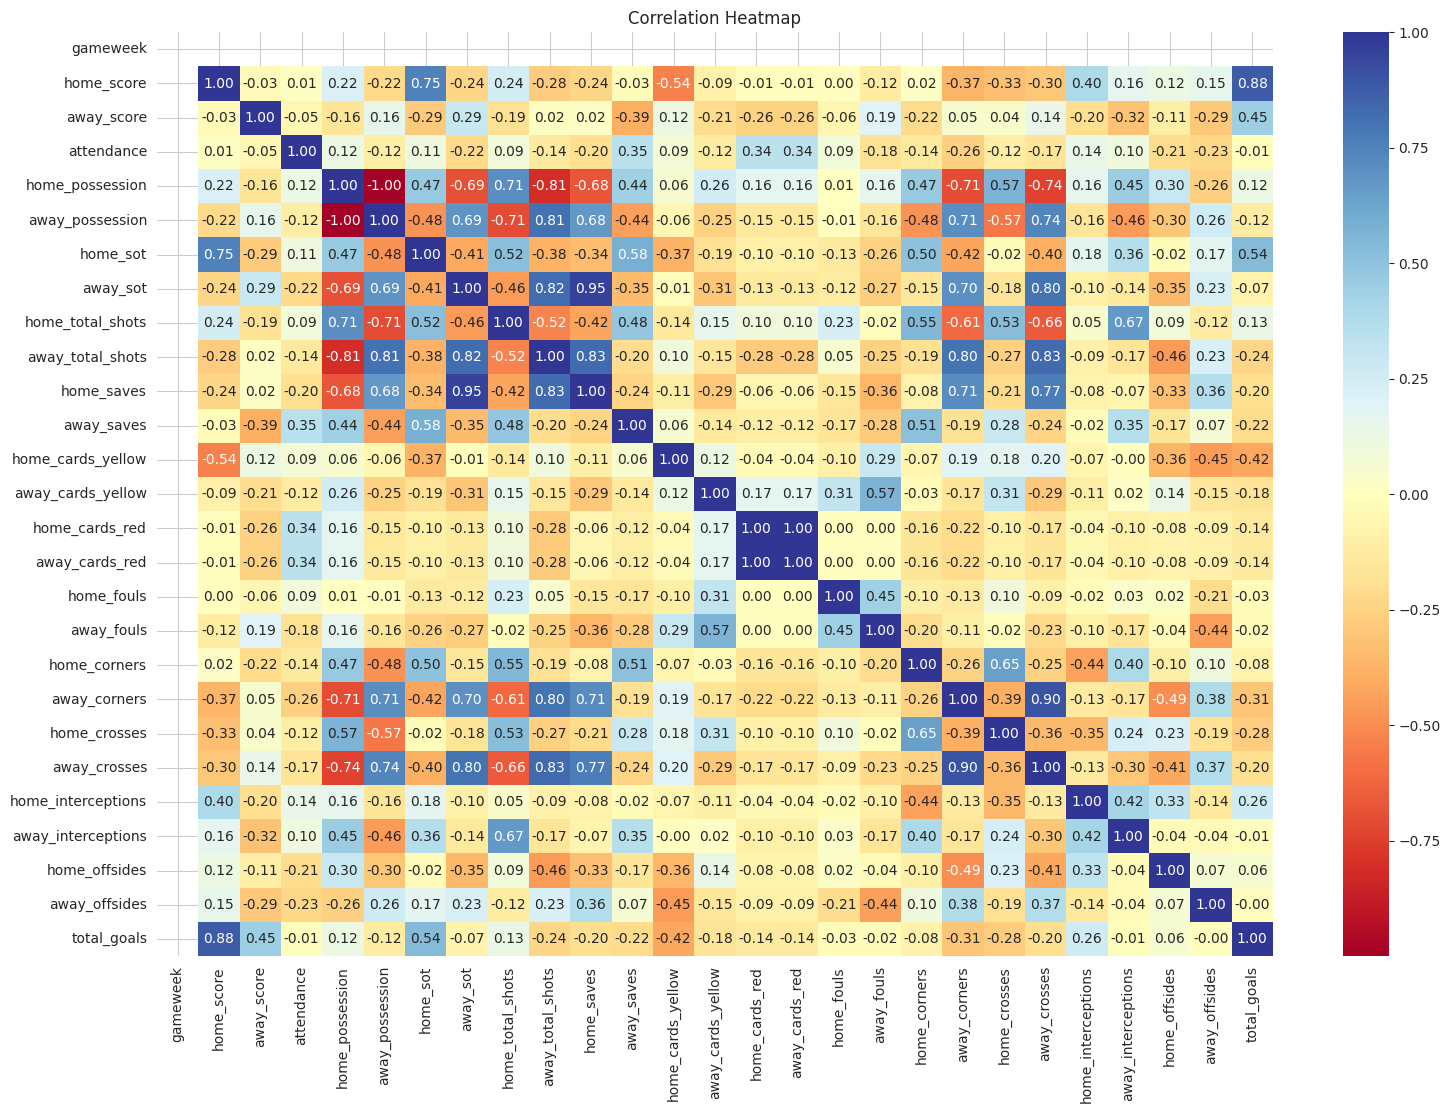

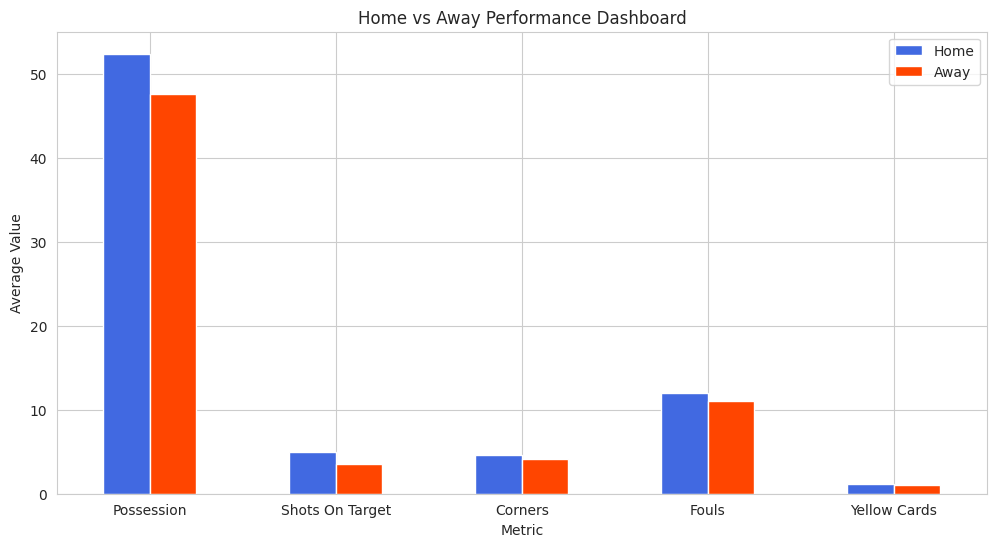

ALL VISUALIZATIONS GENERATED SUCCESSFULLY


In [14]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Convert attendance from string to numeric
df['attendance'] = (
    df['attendance']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['attendance'] = pd.to_numeric(
    df['attendance'],
    errors='coerce'
)

# Drop empty notes column if exists
if 'notes' in df.columns:
    if df['notes'].isnull().sum() == len(df):
        df.drop(columns=['notes'], inplace=True)

# Fill missing offsides values
if 'home_offsides' in df.columns:
    df['home_offsides'].fillna(
        df['home_offsides'].median(),
        inplace=True
    )

if 'away_offsides' in df.columns:
    df['away_offsides'].fillna(
        df['away_offsides'].median(),
        inplace=True
    )

# Create Total Goals
df['total_goals'] = df['home_score'] + df['away_score']

print("Dataset Shape :", df.shape)
print(df.head())

# ==================================================
# STYLE
# ==================================================

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

# ==================================================
# 1 ATTENDANCE DISTRIBUTION
# ==================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['attendance'],
    bins=10,
    kde=True,
    color='purple'
)

plt.title("Attendance Distribution", fontsize=16)
plt.show()

# ==================================================
# 2 HOME VS AWAY GOALS
# ==================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df[['home_score','away_score']],
    palette=['royalblue','orange']
)

plt.title("Home Goals vs Away Goals")
plt.ylabel("Goals")
plt.show()

# ==================================================
# 3 POSSESSION COMPARISON
# ==================================================

possession_df = pd.DataFrame({
    'Type':['Home','Away'],
    'Possession':[
        df['home_possession'].mean(),
        df['away_possession'].mean()
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=possession_df,
    x='Type',
    y='Possession',
    palette=['green','red']
)

plt.title("Average Possession")
plt.show()

# ==================================================
# 4 SHOTS ON TARGET
# ==================================================

sot_df = pd.DataFrame({
    'Type':['Home','Away'],
    'Shots_On_Target':[
        df['home_sot'].mean(),
        df['away_sot'].mean()
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=sot_df,
    x='Type',
    y='Shots_On_Target',
    palette=['dodgerblue','tomato']
)

plt.title("Average Shots On Target")
plt.show()

# ==================================================
# 5 CORNERS ANALYSIS
# ==================================================

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df[['home_corners','away_corners']],
    palette=['blue','red']
)

plt.title("Corners Distribution")
plt.show()

# ==================================================
# 6 YELLOW CARDS
# ==================================================

yellow_cards = pd.DataFrame({
    'Home Yellow':df['home_cards_yellow'],
    'Away Yellow':df['away_cards_yellow']
})

yellow_cards.plot(
    kind='hist',
    bins=10,
    alpha=0.7,
    color=['gold','orange'],
    figsize=(10,6)
)

plt.title("Yellow Cards Distribution")
plt.show()

# ==================================================
# 7 RED CARDS
# ==================================================

plt.figure(figsize=(8,8))

red_counts = [
    df['home_cards_red'].sum(),
    df['away_cards_red'].sum()
]

plt.pie(
    red_counts,
    labels=['Home','Away'],
    autopct='%1.1f%%',
    colors=['crimson','lightcoral']
)

plt.title("Red Cards Distribution")
plt.show()

# ==================================================
# 8 TOP SCORING HOME TEAMS
# ==================================================

top_teams = (
    df.groupby('home_team')['home_score']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_teams.index,
    y=top_teams.values,
    palette='viridis'
)

plt.xticks(rotation=45)
plt.title("Top Home Teams by Goals")
plt.ylabel("Goals")
plt.show()

# ==================================================
# 9 VENUE ATTENDANCE
# ==================================================

venue_attendance = (
    df.groupby('venue')['attendance']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=venue_attendance.values,
    y=venue_attendance.index,
    palette='magma'
)

plt.title("Top Venues by Attendance")
plt.xlabel("Average Attendance")
plt.show()

# ==================================================
# 10 GOALS BY DAY OF WEEK
# ==================================================

weekday_goals = (
    df.groupby('dayofweek')['total_goals']
    .mean()
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=weekday_goals.index,
    y=weekday_goals.values,
    palette='coolwarm'
)

plt.title("Average Goals by Day")
plt.ylabel("Goals")
plt.show()

# ==================================================
# 11 HOME POSSESSION VS GOALS
# ==================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['home_possession'],
    y=df['home_score'],
    color='blue',
    s=120
)

sns.regplot(
    x=df['home_possession'],
    y=df['home_score'],
    scatter=False,
    color='red'
)

plt.title("Home Possession vs Home Goals")
plt.show()

# ==================================================
# 12 TOTAL GOALS DISTRIBUTION
# ==================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['total_goals'],
    bins=8,
    color='darkgreen',
    kde=True
)

plt.title("Total Goals Distribution")
plt.show()

# ==================================================
# 13 HOME VS AWAY FOULS
# ==================================================

fouls = pd.DataFrame({
    'Home':df['home_fouls'].mean(),
    'Away':df['away_fouls'].mean()
}, index=['Fouls'])

fouls.plot(
    kind='bar',
    figsize=(8,5),
    color=['steelblue','salmon']
)

plt.title("Average Fouls")
plt.ylabel("Fouls")
plt.xticks(rotation=0)
plt.show()

# ==================================================
# 14 CORRELATION HEATMAP
# ==================================================

numeric_df = df.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(18,12))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='RdYlBu',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# ==================================================
# 15 MATCH STATISTICS DASHBOARD
# ==================================================

dashboard = pd.DataFrame({
    'Metric':[
        'Possession',
        'Shots On Target',
        'Corners',
        'Fouls',
        'Yellow Cards'
    ],
    'Home':[
        df['home_possession'].mean(),
        df['home_sot'].mean(),
        df['home_corners'].mean(),
        df['home_fouls'].mean(),
        df['home_cards_yellow'].mean()
    ],
    'Away':[
        df['away_possession'].mean(),
        df['away_sot'].mean(),
        df['away_corners'].mean(),
        df['away_fouls'].mean(),
        df['away_cards_yellow'].mean()
    ]
})

dashboard.set_index('Metric').plot(
    kind='bar',
    figsize=(12,6),
    color=['royalblue','orangered']
)

plt.title("Home vs Away Performance Dashboard")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

print("="*50)
print("ALL VISUALIZATIONS GENERATED SUCCESSFULLY")
print("="*50)

## Feature engineering

result
HomeWin    10
Draw        8
AwayWin     2
Name: count, dtype: int64

Target Classes
['AwayWin' 'Draw' 'HomeWin']

Categorical Features
['round', 'dayofweek', 'start_time', 'home_team', 'away_team', 'venue', 'referee', 'home_formation', 'away_formation', 'home_manager', 'away_manager', 'home_captain', 'away_captain']

Numeric Features
['gameweek', 'attendance', 'home_possession', 'away_possession', 'home_sot', 'away_sot', 'home_total_shots', 'away_total_shots', 'home_saves', 'away_saves', 'home_cards_yellow', 'away_cards_yellow', 'home_cards_red', 'away_cards_red', 'home_fouls', 'away_fouls', 'home_corners', 'away_corners', 'home_crosses', 'away_crosses', 'home_interceptions', 'away_interceptions', 'home_offsides', 'away_offsides', 'total_goals']

Train Shape: (16, 42)
Test Shape : (4, 42)


Logistic Regression
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

        Draw    

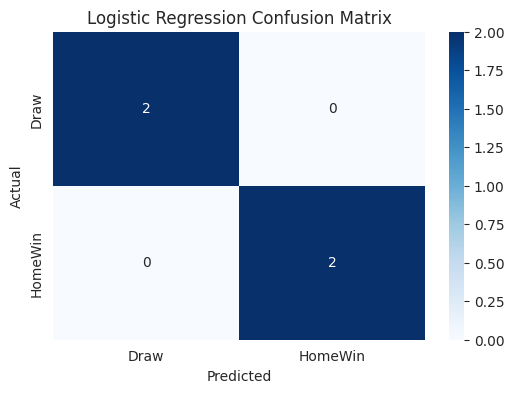



Decision Tree
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report

              precision    recall  f1-score   support

        Draw       1.00      1.00      1.00         2
     HomeWin       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



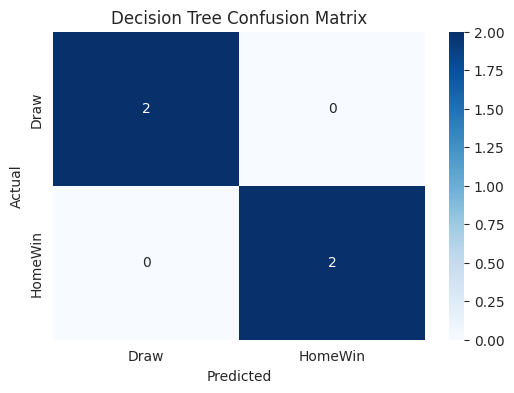



Random Forest
Accuracy  : 0.7500
Precision : 0.8333
Recall    : 0.7500
F1 Score  : 0.7333

Classification Report

              precision    recall  f1-score   support

        Draw       1.00      0.50      0.67         2
     HomeWin       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



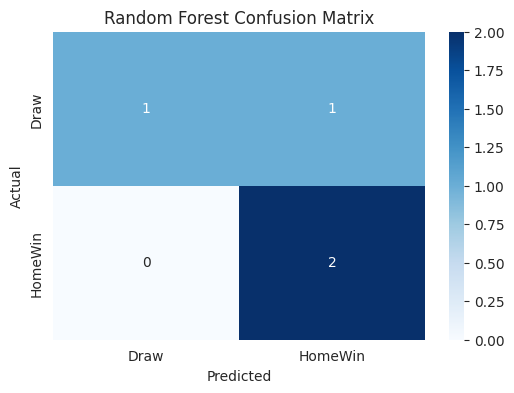


Model Comparison
                 Model  Accuracy  Precision  Recall        F1
0  Logistic Regression      1.00   1.000000    1.00  1.000000
1        Decision Tree      1.00   1.000000    1.00  1.000000
2        Random Forest      0.75   0.833333    0.75  0.733333


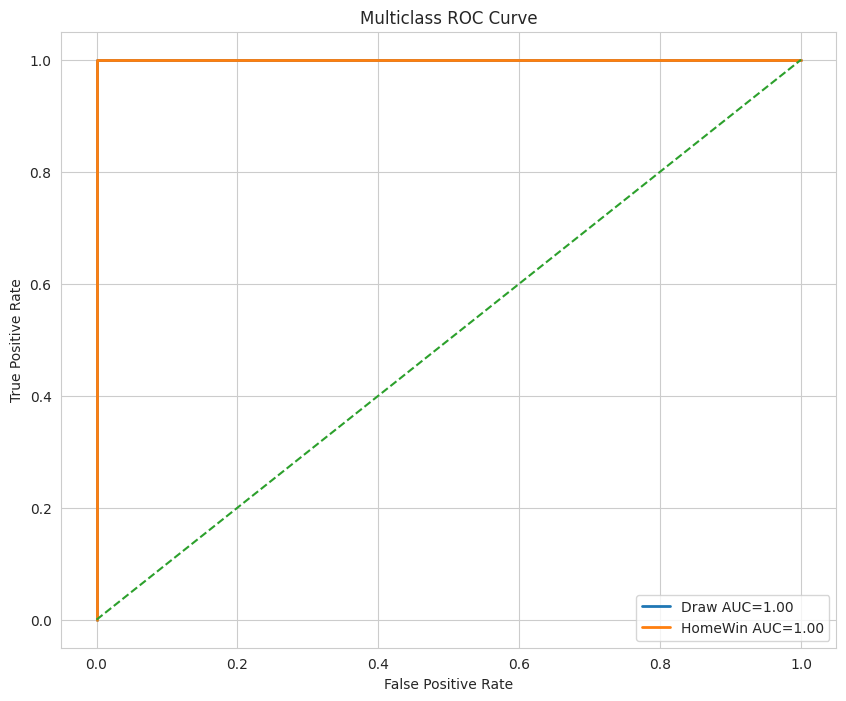

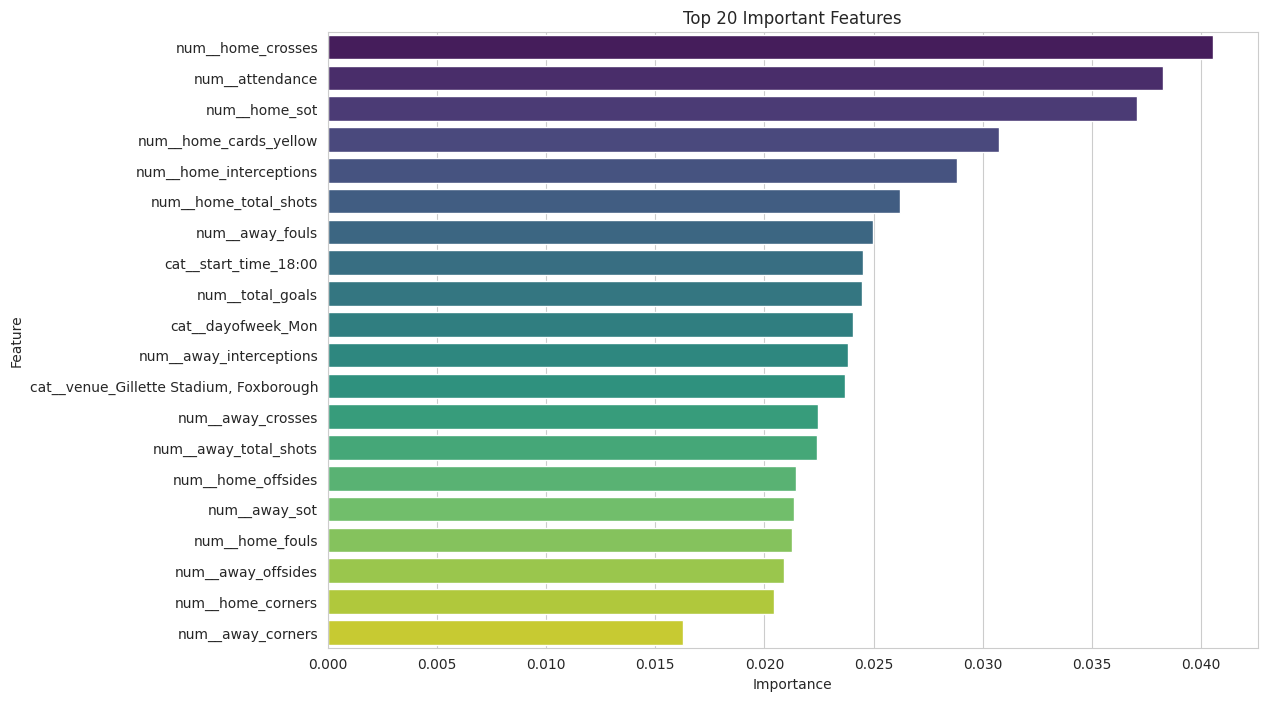


Pipeline Completed Successfully


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# =========================================================
# DATA CLEANING
# =========================================================

df['date'] = pd.to_datetime(df['date'])

# Attendance cleaning

df['attendance'] = (
    df['attendance']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['attendance'] = pd.to_numeric(
    df['attendance'],
    errors='coerce'
)

# Fill missing values

df['home_offsides'] = df['home_offsides'].fillna(
    df['home_offsides'].median()
)

df['away_offsides'] = df['away_offsides'].fillna(
    df['away_offsides'].median()
)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday_num'] = df['date'].dt.weekday

# =========================================================
# CREATE TARGET
# =========================================================

def create_result(row):

    if row['home_score'] > row['away_score']:
        return 'HomeWin'

    elif row['home_score'] < row['away_score']:
        return 'AwayWin'

    else:
        return 'Draw'

df['result'] = df.apply(
    create_result,
    axis=1
)

print(df['result'].value_counts())

# =========================================================
# REMOVE LEAKAGE
# =========================================================

drop_cols = [
    'score',
    'home_score',
    'away_score',
    'result',
    'date'
]

if 'notes' in df.columns:
    drop_cols.append('notes')

X = df.drop(columns=drop_cols)

y = df['result']

# =========================================================
# ENCODE TARGET
# =========================================================

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("\nTarget Classes")
print(le.classes_)

# =========================================================
# FEATURE TYPES
# =========================================================

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

numeric_features = X.select_dtypes(
    include=['int64','float64']
).columns.tolist()

print("\nCategorical Features")
print(categorical_features)

print("\nNumeric Features")
print(numeric_features)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# =========================================================
# PREPROCESSOR
# =========================================================

numeric_transformer = Pipeline(
    steps=[
        ('imputer',
         SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer',
         SimpleImputer(strategy='most_frequent')),

        ('encoder',
         OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),

        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

# =========================================================
# MODELS
# =========================================================

models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "Decision Tree":
    DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )
}

# =========================================================
# TRAIN MODELS
# =========================================================

results = []

for name, model in models.items():

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    # =====================================================
    # SAFE CLASSIFICATION REPORT
    # =====================================================

    labels_present = np.unique(
        np.concatenate([y_test, y_pred])
    )

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            y_pred,
            labels=labels_present,
            target_names=le.inverse_transform(
                labels_present
            ),
            zero_division=0
        )
    )

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels_present
    )

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.inverse_transform(
            labels_present
        ),
        yticklabels=le.inverse_transform(
            labels_present
        )
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# =========================================================
# MODEL COMPARISON
# =========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1'
    ]
)

print("\nModel Comparison")
print(results_df)

# =========================================================
# BEST MODEL FOR ROC
# =========================================================

rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        (
            'model',
            RandomForestClassifier(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

# =========================================================
# SAFE MULTI-CLASS ROC
# =========================================================

y_prob = rf_pipeline.predict_proba(
    X_test
)

n_classes = len(le.classes_)

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(n_classes)
)

plt.figure(figsize=(10,8))

for i in range(n_classes):

    if y_test_bin[:, i].sum() == 0:
        continue

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{le.classes_[i]} AUC={roc_auc:.2f}'
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

try:

    feature_names = (
        rf_pipeline
        .named_steps['preprocessor']
        .get_feature_names_out()
    )

    importances = (
        rf_pipeline
        .named_steps['model']
        .feature_importances_
    )

    importance_df = pd.DataFrame({

        'Feature': feature_names,
        'Importance': importances

    })

    importance_df = (
        importance_df
        .sort_values(
            by='Importance',
            ascending=False
        )
        .head(20)
    )

    plt.figure(figsize=(12,8))

    sns.barplot(
        data=importance_df,
        x='Importance',
        y='Feature',
        palette='viridis'
    )

    plt.title(
        'Top 20 Important Features'
    )

    plt.show()

except Exception as e:

    print(
        "Feature Importance Error:",
        e
    )

print("\nPipeline Completed Successfully")

## Thank you....pls upvote!!!!!!!!!!